In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def get_angle(v1, v2, v3):
    dot = np.dot(v1-v2, v1-v3)
    cross = ((v1-v2)[0])*((v1-v3)[1]) - ((v1-v2)[1])*((v1-v3)[0])
    return np.arctan2(cross, dot)

In [3]:
def get_grads(j, dist, angle, h=1e-4): #Gets del(Ej)/del(xk) over k
    v = np.zeros((6, 2))
    grad = np.zeros((6, 2))
    v[0] = np.zeros(2)
    v[1] = np.array([dist[0]*np.cos(angle[0]), dist[0]*np.sin(angle[0])])
    v[2] = np.array([dist[1]*np.cos(angle[1]), dist[1]*np.sin(angle[1])])
    v[3] = np.array([dist[2]*np.cos(angle[2]), dist[2]*np.sin(angle[2])])
    v[4] = np.array([dist[3]*np.cos(angle[3]), dist[3]*np.sin(angle[3])])
    v[5] = np.array([dist[4]*np.cos(angle[4]), dist[4]*np.sin(angle[4])])
    for i in range(1, 6):
        v[i, 0] = v[i, 0] + h
        Epx = get_energy(v, thetareq[j])
        v[i, 0] = v[i, 0] - 2*h
        Emx = get_energy(v, thetareq[j])
        v[i, 0] = v[i, 0] + h
        v[i, 1] = v[i, 1] + h
        Epy = get_energy(v, thetareq[j])
        v[i, 1] = v[i, 1] - 2*h
        Emy = get_energy(v, thetareq[j])
        v[i, 1] = v[i, 1] + h
        
        grad[i, :] = np.array([(Epx-Emx)/(2*h), (Epy-Emy)/(2*h)]) #del(Ej)/del(vi) = del(Ej)/del(xi)
        
    grad[0, :] = -(grad[1, :] + grad[2, :] + grad[3, :] + grad[4, :] + grad[5, :]) #del(Ej)/del(xj) = -sum(del(Ej)/del(vk))
    return grad

In [19]:
def get_energy(vec, reqd_angles):
    angle1 = get_angle(vec[0], vec[1], vec[2])
    angle2 = get_angle(vec[0], vec[1], vec[3])
    angle3 = get_angle(vec[0], vec[1], vec[4])
    angle4 = get_angle(vec[0], vec[1], vec[5])
    E = 4 - np.cos(angle1 - reqd_angles[0]) - np.cos(angle2 - reqd_angles[1]) - np.cos(angle3 - reqd_angles[2]) - np.cos(angle4 - reqd_angles[3]) + 0.01*((1/np.linalg.norm(vec[1] - vec[0])) + (1/np.linalg.norm(vec[2] - vec[0])) + (1/np.linalg.norm(vec[3] - vec[0])) + (1/np.linalg.norm(vec[4] - vec[0])) + (1/np.linalg.norm(vec[5] - vec[0])))
    return E

In [5]:
def evolve(positions, thetareq, alpha = 1e-3):
    E = 0
    grads = np.zeros(np.shape(positions))
    for i in range(6): #Decides which bot is in the active phase currently
        v1 = positions[i]
        v2 = positions[(i+1)%6]
        v3 = positions[(i+2)%6]
        v4 = positions[(i+3)%6]
        v5 = positions[(i+4)%6]
        v6 = positions[(i+5)%6]
        ref = np.array([1, 0])
        dist = np.array([np.linalg.norm(v1-v2), np.linalg.norm(v1-v3), np.linalg.norm(v1-v4), np.linalg.norm(v1-v5), np.linalg.norm(v1-v6)]) #Gets perfect distance data. The bot does this using distance data frm intensity values
        angle = np.array([get_angle(v1, v1+ref, v2), get_angle(v1, v1+ref, v3), get_angle(v1, v1+ref, v4), get_angle(v1, v1+ref, v5), get_angle(v1, v1+ref, v6)]) #Gets perfect angle data. The bot does this using bearing data from IR detectors
        diff = np.roll(get_grads(i, dist, angle), i , axis=0) #Gets grads corresponding to Ei, rolls the matrix to ensure bot-wise gradient ordering
        grads = grads + diff
        E2 = get_energy(np.array([v1, v2, v3, v4, v5, v6]), thetareq[i]) #Gets energy of the current configuration wrt bot i
        #E.append(diff)
        E = E + E2
    new_positions = positions - alpha*grads
    return new_positions, E, grads

In [6]:
def total_energy(positions, thetareqd):
    E = 0
    for i in range(6):
        E = E + get_energy(np.roll(positions, -i, axis = 0), thetareqd[i])
    return E

Firstly, lets try to form a hexagon

In [20]:
thetareq1 = np.array([30, 60, 90, 120])*(np.pi/180)
thetareq2 = np.array([30, 60, 90, 120])*(np.pi/180)
thetareq3 = np.array([30, 60, 90, 120])*(np.pi/180)
thetareq4 = np.array([30, 60, 90, 120])*(np.pi/180)
thetareq5 = np.array([30, 60, 90, 120])*(np.pi/180)
thetareq6 = np.array([30, 60, 90, 120])*(np.pi/180)
thetareq = np.array([thetareq1, thetareq2, thetareq3, thetareq4, thetareq5, thetareq6])
positions = np.random.randn(6, 2) * 2

In [ ]:
E = 30
step = 0
while E > 0.02:
    positions, E, grads = evolve(positions, thetareq)
    if step%10 ==0:
        print(E)
plt.scatter(positions[:, 0], positions[:, 1], color = 'red', s = 5)
plt.show()

16.384970126560038
16.36852479526128
16.35209155037211
16.335669921625968
16.319259439921574
16.30285963731288
16.286470046998303
16.27009020330868
16.253719641694126
16.23735789871058
16.22100451200462
16.204659020298042
16.18832096337096
16.171989882044596
16.15566531816268
16.13934681457237
16.123033915104372
16.106726164552065
16.090423108649652
16.074124294050264
16.057829268302523
16.041537579826795
16.02524877789069
16.008962412583585
15.992678034790735
15.976395196166635
15.960113449107658
15.943832346723987
15.927551442810877
15.91127029181951
15.894988448826906
15.87870546950539
15.862420910091217
15.846134327353251
15.829845278559855
15.81355332144642
15.797258014181585
15.780958915332958
15.764655583832507
15.748347578941187
15.73203446021294
15.715715787458361
15.699391120707823
15.6830600201734
15.666722046211301
15.650376759282851
15.634023719915408
15.617662488662667
15.601292626064055
15.58491369260436
15.568525248671932
15.552126854516896
15.535718070208826
15.5192984

KeyboardInterrupt: 

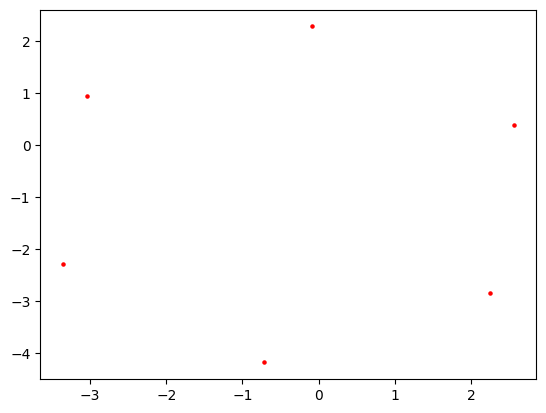

In [22]:
plt.scatter(positions[:, 0], positions[:, 1], color = 'red', s = 5)
plt.show()

In [23]:
print(np.linalg.norm(positions[0] - positions[1]))
print(np.linalg.norm(positions[1] - positions[2]))
print(np.linalg.norm(positions[2] - positions[3]))
print(np.linalg.norm(positions[3] - positions[4]))
print(np.linalg.norm(positions[4] - positions[5]))
print(np.linalg.norm(positions[5] - positions[0]))

3.2525422065322256
3.2525430152574555
3.2525421771074403
3.2525422889708633
3.252542932818647
3.2525422595448674


Stuff required to be added:
1. Accounting for measurement noise and errors
2. Realistic step sizes based on limitations on Vibration motors
3. Other shapes

Let's try a boat shape this time

In [24]:
positions = np.zeros((6,2))
positions[0, :] = np.array([0, 0])
positions[1, :] = np.array([5, 0])
positions[2, :] = np.array([5, 5])
positions[3, :] = np.array([10/3, 5/2])
positions[4, :] = np.array([5/3, 5/2])
positions[5, :] = np.array([0, 5])
for i in range(6):
    thetareq[i, :] = np.array([get_angle(positions[i, :], positions[(i+1)%6, :], positions[(i+2)%6, :]), get_angle(positions[i, :], positions[(i+1)%6, :], positions[(i+3)%6, :]), get_angle(positions[i, :], positions[(i+1)%6, :], positions[(i+4)%6, :]), get_angle(positions[i, :], positions[(i+1)%6, :], positions[(i+5)%6, :])])
positions = np.random.randn(6, 2) * 2

15.931215811688471
15.88085387693641
15.829620422086519
15.777488170170137
15.724429959599286
15.670418825631998
15.615428091109877
15.55943146671186
15.502403160893184
15.44431799958796
15.385151555647573
15.324880287858022
15.263481689239939
15.200934444169256
15.137218593679888
15.072315708111914
15.00620906606158
14.938883838366785
14.870327275636061
14.800528897596779
14.7294806823124
14.657177253101231
14.583616060788712
14.508797558749825
14.432725368056282
14.355406429942347
14.276851142751974
14.19707348053715
14.116091090543769
14.0339253669615
13.950601498518928
13.866148487787335
13.78059914040186
13.693990022823641
13.606361387736184
13.517757066682456
13.428224330103452
13.337813715503367
13.246578825042063
13.154576094412658
13.061864535386317
12.968505454890355
12.87456215390302
12.780099609790353
12.685184145974926
12.589883092993455
12.494264445080107
12.398396516395568
12.30234760091722
12.206185639818571
12.109977899906237
12.013790666362182
11.917688952662116
11.82

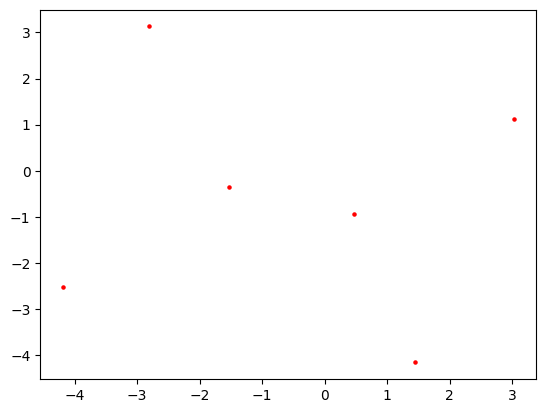

In [26]:
E = 30
step = 0
while E > 0.08:
    positions, E, grads = evolve(positions, thetareq)
    if step%10 ==0:
        print(E)
    step = step + 1
plt.scatter(positions[:, 0], positions[:, 1], color = 'red', s = 5)
plt.show()

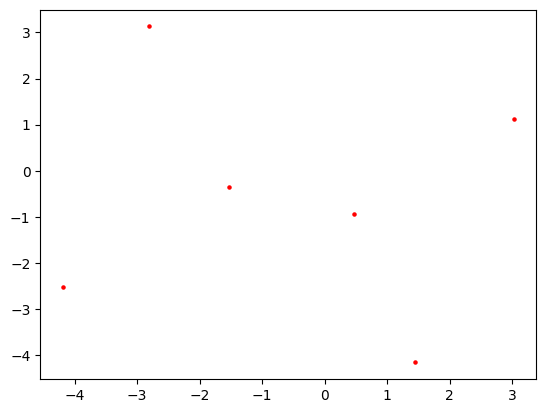

In [27]:
plt.scatter(positions[:, 0], positions[:, 1], color = 'red', s = 5)
plt.show()